/Users/rubenhayrapetyan/Library/Python/3.9/lib/python/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/Users/rubenhayrapetyan/Library/Python/3.9/lib/python/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


Epoch [1/10]
Training loss 2.2481575514722594
Training accuracy 18.079505517797802 %
Testing loss 2.2277466493218534
Testing accuracy 19.587430854333128 %
Epoch [2/10]
Training loss 2.2383088347757134
Training accuracy 19.106746997783187 %
Testing loss 2.2264571970932017
Testing accuracy 19.587430854333128 %
Epoch [3/10]
Training loss 2.2386656718851463
Training accuracy 19.11457551226571 %
Testing loss 2.226807214470824
Testing accuracy 19.587430854333128 %
Epoch [4/10]
Training loss 2.2412705126384145
Training accuracy 18.819258954866104 %
Testing loss 2.227042571855016
Testing accuracy 19.587430854333128 %
Epoch [5/10]
Training loss 2.237512193221656
Training accuracy 19.140034071550257 %
Testing loss 2.2265394490118324
Testing accuracy 19.587430854333128 %
Epoch [6/10]
Training loss 2.2411315717676326
Training accuracy 18.87024150634466 %
Testing loss 2.2264553570058645
Testing accuracy 19.587430854333128 %
Epoch [7/10]
Training loss 2.239193877440981
Training accuracy 18.959537572

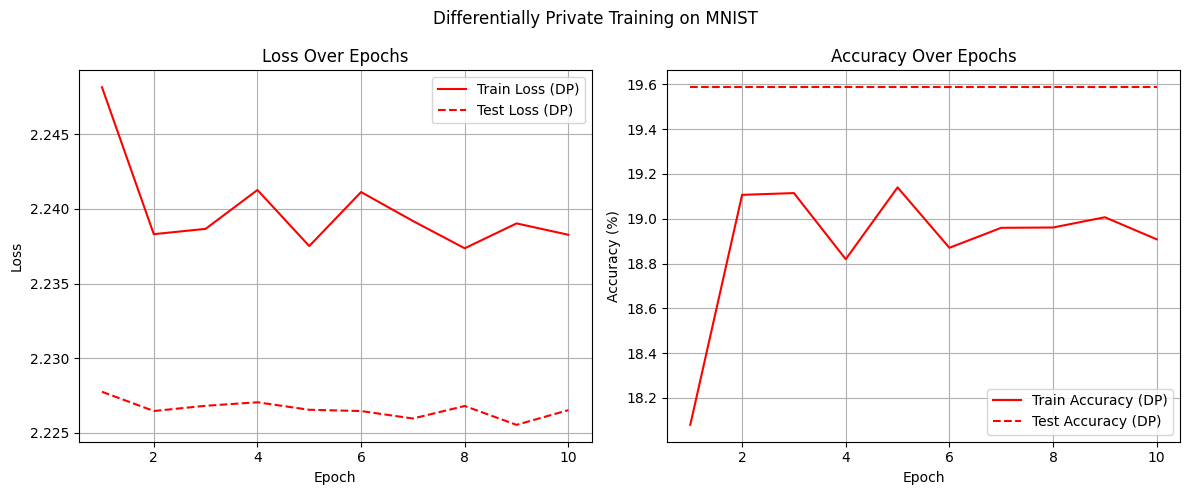


Privacy Budget Used:
Epsilon: 2.9922
Delta: 1e-5


In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import gc
from opacus import PrivacyEngine
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Data loading and preprocessing
transform_svhn = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Grayscale(),
])

svhn_dataset  = datasets.SVHN(root='./data', split="train", transform=transform_svhn, download=True)
svhn_loader  = DataLoader(dataset=svhn_dataset, batch_size=64, shuffle=False)

cifar_test_data = datasets.SVHN(root='./data', split="test", transform=transform_svhn, download=True)
test_loader = DataLoader(dataset=cifar_test_data, batch_size=64, shuffle=False)

# Model definition
class mnist(nn.Module):
    def __init__(self):
        super(mnist, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2)
        self.tanh1 = nn.Tanh()
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        self.tanh2 = nn.Tanh()
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1)
        self.tanh3 = nn.Tanh()
        self.fc1 = nn.Linear(120, 84)
        self.tanh4 = nn.Tanh()
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(self.tanh1(self.conv1(x)))
        x = self.pool2(self.tanh2(self.conv2(x)))
        x = self.tanh3(self.conv3(x))
        x = x.view(-1, 120)  # Flatten the tensor
        x = self.tanh4(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize model, criterion, and optimizer
model = mnist()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# Initialize privacy engine
privacy_engine = PrivacyEngine()

# Make the model private
model, optimizer, svhn_loader = privacy_engine.make_private_with_epsilon(
    module=model,
    optimizer=optimizer,
    data_loader=svhn_loader,
    epochs=10,
    target_epsilon=3,
    target_delta=1e-5,
    max_grad_norm=0.1,
)

# Training loop
epochs = 10
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in svhn_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    print(f'Epoch [{epoch + 1}/{epochs}]')
    print("Training loss", (running_loss / total))
    train_losses.append(running_loss / total)
    print("Training accuracy", (correct * 100 / total), '%')
    train_accuracies.append(correct * 100 / total)
    gc.collect()

    # Evaluation
    model.eval()
    running_loss_eval = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss_eval += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print("Testing loss", (running_loss_eval / total))
    test_losses.append(running_loss_eval / total)
    print("Testing accuracy", (correct * 100 / total), '%')
    test_accuracies.append(correct * 100 / total)
    gc.collect()

# Final evaluation
model.eval()
correct = 0
total = 0
eval_loss = 0.0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        eval_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"Final Test Loss: {eval_loss / total:.4f}, Accuracy: {100 * correct / total:.2f}%")

# Plotting
plt.figure(figsize=(12, 5))
plt.suptitle('Differentially Private Training on MNIST')

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, 'r-', label='Train Loss (DP)')
plt.plot(range(1, epochs + 1), test_losses, 'r--', label='Test Loss (DP)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()
plt.grid(True)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_accuracies, 'r-', label='Train Accuracy (DP)')
plt.plot(range(1, epochs + 1), test_accuracies, 'r--', label='Test Accuracy (DP)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print privacy budget spent
print(f"\nPrivacy Budget Used:")
print(f"Epsilon: {privacy_engine.get_epsilon(delta=1e-5):.4f}")
print(f"Delta: 1e-5")
